# Template Matching
Find a logo/sticker in multiple product photos using TM_CCOEFF_NORMED

In [ ]:
import cv2
import argparse
import matplotlib.pyplot as plt


(np.float64(-0.5), np.float64(406.5), np.float64(657.5), np.float64(-0.5))

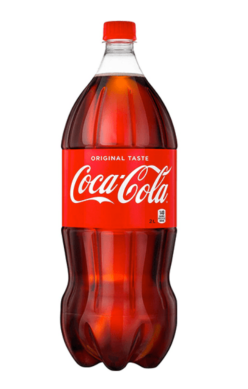

In [ ]:
image = cv2.imread("/content/coca-cola.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.axis("off")

In [ ]:
template = cv2.imread("/content/template.png")
template = cv2.cvtColor(template, cv2.COLOR_BGR2RGB)
plt.imshow(template)
plt.axis("off")

In [ ]:
imageGray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
templateGray = cv2.cvtColor(template,cv2.COLOR_BGR2GRAY)

In [ ]:
result = cv2.matchTemplate(imageGray,templateGray,cv2.TM_CCOEFF_NORMED)
(minVal,maxVal,minLoc,maxLoc) = cv2.minMaxLoc(result)

In [ ]:
(startX,startY) = maxLoc
endX = startX + template.shape[1]
endY = startY + template.shape[0]

In [ ]:
cv2.rectangle(image, (startX, startY), (endX, endY), (0, 255, 0), 3)
# show the output image
plt.imshow(image)
plt.axis("off")


# Shape Matching

Classify simple shapes (circle,square,triangle) using Hu moments

In [ ]:
def get_hu_moments(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 170, 255, 0)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    cnt = max(contours, key=cv2.contourArea)  # largest object
    moments = cv2.moments(cnt)
    hu = cv2.HuMoments(moments)
    return hu, cnt

In [ ]:
templates = {
    "Triangle": "/content/traingle.png",
    "Square": "/content/square.png",
    "Circle": "/content/circle.png"
}

template_contours = {}

for name, path in templates.items():
    hu, cnt = get_hu_moments(path)
    template_contours[name] = cnt

In [ ]:
input_path = '/content/shape_descriptor2.png'

img = cv2.imread(input_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 170, 255, 0)

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for cnt in contours:
    best_match = None
    lowest_score = float("inf")

    for name, tmpl_cnt in template_contours.items():
        score = cv2.matchShapes(cnt, tmpl_cnt, cv2.CONTOURS_MATCH_I1, 0)

        if score < lowest_score:
            lowest_score = score
            best_match = name

    x, y = cnt[0, 0]

    cv2.drawContours(img, [cnt], -1, (0, 255, 255), 3)
    cv2.putText(img, best_match, (x, y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                (255, 0, 0), 2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

# Face detection: Run Haar cascade on webcam + group photos → count faces, draw boxes.


In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import files

In [ ]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

In [ ]:
uploaded = files.upload()

Saving group_photo.png to group_photo.png


In [ ]:
for filename in uploaded.keys():

    # Read image
    img = cv2.imread(filename)

    # Convert to grayscale (Haar works on gray images)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.3,
        minNeighbors=5
    )

    print("Number of faces detected:", len(faces))

    # Draw bounding boxes
    for (x, y, w, h) in faces:
        cv2.rectangle(
            img,
            (x, y),
            (x+w, y+h),
            (0, 255, 0),
            2
        )

    # Show result
    cv2_imshow(img)

### Webcam Face Detection

In [ ]:
from IPython.display import Javascript
from google.colab.output import eval_js
from base64 import b64decode
import PIL.Image
import io

In [ ]:
def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getVideoTracks()[0].stop();
      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
  ''')

  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])

  with open(filename, 'wb') as f:
      f.write(binary)

  return filename

In [ ]:
photo = take_photo()
img = cv2.imread(photo)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray,1.3,5)

print("Faces detected:",len(faces))

for (x,y,w,h) in faces:
    cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)

cv2_imshow(img)

# Build a “LEGO brick detector” : use template matching + contour filtering

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import files

In [ ]:
img_scene =  cv2.imread("/content/lego_scene2.png")
img_scene = cv2.cvtColor(img_scene, cv2.COLOR_BGR2RGB)
plt.imshow(img_scene)

In [ ]:
img_temp =  cv2.imread("/content/lego_template2.png")
img_temp = cv2.cvtColor(img_temp, cv2.COLOR_BGR2RGB)
plt.imshow(img_temp)

In [ ]:
img_scene_gray = cv2.cvtColor(img_scene, cv2.COLOR_RGB2GRAY)

# Apply adaptive thresholding to better separate objects with varying lighting
# You might need to adjust the block size and C parameter based on your image
img_scene_thresh = cv2.adaptiveThreshold(img_scene_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

# Find contours
contours, _ = cv2.findContours(img_scene_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Create a copy of the original image to draw contours on
img_contours = img_scene.copy()

# Draw contours on the image
# Filter out very small contours that might be noise
lego_bricks = []
min_area = 100 # Adjust this value as needed

for i, contour in enumerate(contours):
    area = cv2.contourArea(contour)
    if area > min_area:
        # You can store the contours or draw them
        lego_bricks.append(contour)
        cv2.drawContours(img_contours, [contour], -1, (0, 255, 0), 2) # Green contours

print(f"Found {len(lego_bricks)} potential LEGO bricks.")

# Display the thresholded image and the image with contours
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_scene_thresh, cmap='gray')
plt.title('Thresholded Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_contours)
plt.title('Detected LEGO Bricks (Contours)')
plt.axis('off')
plt.show()

In [ ]:
# Convert scene image to grayscale for template matching
img_scene_gray = cv2.cvtColor(img_scene, cv2.COLOR_RGB2GRAY)

# Convert template image to grayscale
img_temp_gray = cv2.cvtColor(img_temp, cv2.COLOR_RGB2GRAY)
(tH, tW) = img_temp_gray.shape[:2]

# Create a copy of the scene image to draw results on
img_result = img_scene.copy()

match_threshold = 0.53 # Adjusted threshold for matching sensitivity

# Define rotation angles to test (0, 90, 180, 270 degrees clockwise)
ROTATION_MODES = [
    ("0 deg", None),
    ("90 deg CW", cv2.ROTATE_90_CLOCKWISE),
    ("180 deg", cv2.ROTATE_180),
    ("270 deg CW", cv2.ROTATE_90_COUNTERCLOCKWISE)
]

all_detections = [] # Store (startX, startY, endX, endY, score, rotation_name)

print(f"Searching for all instances of the template (dim: {tW}x{tH}) using rotation-invariant matching.")

# Iterate through each rotation mode for the template
for rotation_name, rotation_mode in ROTATION_MODES:
    current_img_temp_rotated_gray = img_temp_gray
    current_tH, current_tW = tH, tW

    if rotation_mode is not None:
        current_img_temp_rotated = cv2.rotate(img_temp, rotation_mode)
        current_img_temp_rotated_gray = cv2.cvtColor(current_img_temp_rotated, cv2.COLOR_RGB2GRAY)
        current_tH, current_tW = current_img_temp_rotated_gray.shape[:2]

    # Perform template matching
    result = cv2.matchTemplate(img_scene_gray, current_img_temp_rotated_gray, cv2.TM_CCOEFF_NORMED)

    # Find all locations where the match score is above the threshold
    loc = np.where(result >= match_threshold)

    for pt in zip(*loc[::-1]): # Iterate over all found locations
        startX, startY = pt[0], pt[1]
        endX = startX + current_tW
        endY = startY + current_tH
        score = result[startY, startX]
        all_detections.append((startX, startY, endX, endY, score, rotation_name))

# Prepare data for NMS
bboxes = []
scores_for_nms = []
for det in all_detections:
    # Convert (startX, startY, endX, endY) to (x, y, w, h) for NMSBoxes
    x = det[0]
    y = det[1]
    w = det[2] - det[0]
    h = det[3] - det[1]
    bboxes.append([x, y, w, h])
    scores_for_nms.append(det[4]) # The score

# Apply non-maxima suppression to remove overlapping bounding boxes
# NMSBoxes returns the indices of the bounding boxes to keep
indices = cv2.dnn.NMSBoxes(bboxes, scores_for_nms, match_threshold, 0.3) # 0.3 is overlapThreshold (adjust as needed)

matched_count = 0
if len(indices) > 0:
    for i in indices.flatten():
        # Retrieve the original detection details from all_detections
        det_info = all_detections[i]
        startX, startY, endX, endY, score, rotation_name = det_info

        matched_count += 1

        cv2.rectangle(img_result, (startX, startY), (endX, endY), (0, 255, 0), 3) # Green rectangle
        cv2.putText(img_result, f"Match: {score:.2f} ({rotation_name})", (startX, startY - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

# Display the results with all matches highlighted
plt.figure(figsize=(12, 10))
plt.imshow(img_result)
plt.title(f"Rotation-Invariant Template Matching: {matched_count} matches found (threshold={match_threshold:.2f})")
plt.axis('off')
plt.show()

print(f"Total unique matched bricks found after NMS: {matched_count}")

# Run Haar face detector vs. a modern deep detector (e.g., MediaPipe) on the same video → compare speed & accuracy.


In [5]:
# Install MediaPipe
!pip install mediapipe

import cv2
import mediapipe as mp
import time
import numpy as np
from google.colab.patches import cv2_imshow

In [ ]:
!wget https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml
haar_face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

## Haar Cascade on video


In [13]:
from google.colab import files
uploaded = files.upload()

Saving 5940471-uhd_3840_2160_25fps.mp4 to 5940471-uhd_3840_2160_25fps.mp4


In [8]:
import cv2
import time
from google.colab import files

# Upload video
uploaded = files.upload()
video_path = list(uploaded.keys())[0]

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

cap = cv2.VideoCapture(video_path)

width = int(cap.get(3))
height = int(cap.get(4))
fps = int(cap.get(cv2.CAP_PROP_FPS))

out = cv2.VideoWriter('haar_output.mp4',
                      cv2.VideoWriter_fourcc(*'mp4v'),
                      fps,
                      (width, height))

frame_count = 0
processed_frames = 0
total_faces = 0

skip_frames = 3

start_time = time.time()

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    if frame_count % skip_frames != 0:
        continue

    processed_frames += 1

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.1, 5)

    total_faces += len(faces)

    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)

    out.write(frame)

end_time = time.time()

cap.release()
out.release()

# Metrics
time_taken = end_time - start_time
fps_processed = processed_frames / time_taken

print("HAAR CASCADE RESULTS")
print("Total frames read:", frame_count)
print("Frames processed:", processed_frames)
print("Time taken:", round(time_taken, 2), "seconds")
print("Processing FPS:", round(fps_processed, 2))
print("Total faces detected:", total_faces)

files.download('haar_output.mp4')

Saving 5940471-uhd_3840_2160_25fps.mp4 to 5940471-uhd_3840_2160_25fps (1).mp4
HAAR CASCADE RESULTS
Total frames read: 349
Frames processed: 116
Time taken: 246.56 seconds
Processing FPS: 0.47
Total faces detected: 775


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Mediapipe


In [ ]:
!pip install mediapipe opencv-python-headless

In [2]:
import mediapipe as mp
print(dir(mp))

['Image', 'ImageFormat', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'tasks']


In [ ]:
!wget -O face_detector.tflite \
https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/latest/blaze_face_short_range.tflite

In [9]:
import cv2
import mediapipe as mp
import time

BaseOptions = mp.tasks.BaseOptions
FaceDetector = mp.tasks.vision.FaceDetector
FaceDetectorOptions = mp.tasks.vision.FaceDetectorOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = FaceDetectorOptions(
    base_options=BaseOptions(model_asset_path='face_detector.tflite'),
    running_mode=VisionRunningMode.VIDEO
)

detector = FaceDetector.create_from_options(options)

cap = cv2.VideoCapture('/content/5940471-uhd_3840_2160_25fps.mp4')

width = int(cap.get(3))
height = int(cap.get(4))
fps = int(cap.get(cv2.CAP_PROP_FPS))

out = cv2.VideoWriter('mediapipe_output.mp4',
                      cv2.VideoWriter_fourcc(*'mp4v'),
                      fps,
                      (width, height))

frame_count = 0
total_faces = 0

start_time = time.time()
timestamp = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

    results = detector.detect_for_video(mp_image, timestamp)
    timestamp += int(1000 / fps)

    detections = results.detections if results.detections else []
    total_faces += len(detections)

    for detection in detections:
        bbox = detection.bounding_box
        x, y, w, h = bbox.origin_x, bbox.origin_y, bbox.width, bbox.height
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)

    out.write(frame)

end_time = time.time()

cap.release()
out.release()

# Metrics
time_taken = end_time - start_time
fps_processed = frame_count / time_taken

print("\nMEDIAPIPE RESULTS")
print("Total frames processed:", frame_count)
print("Time taken:", round(time_taken, 2), "seconds")
print("Processing FPS:", round(fps_processed, 2))
print("Total faces detected:", total_faces)

files.download('mediapipe_output.mp4')


MEDIAPIPE RESULTS
Total frames processed: 349
Time taken: 25.7 seconds
Processing FPS: 13.58
Total faces detected: 664


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion

## Performance Analysis (Speed)
* Haar Cascade achieved a processing speed of 0.47 FPS, taking 246.56 seconds to process the video.
*  MediaPipe achieved 13.58 FPS, completing the same task in 25.7 seconds.

👉 This demonstrates that MediaPipe is ~28× faster than Haar Cascade in this setup.

## Detection Analysis (Accuracy Proxy)
* Haar Cascade is known to produce false positives (detecting non-face regions as faces)
* MediaPipe provides more precise and consistent detections due to its deep learning-based architecture

👉 Therefore, the higher count in Haar Cascade likely indicates lower precision, not better accuracy.

MediaPipe significantly outperforms Haar Cascade in both speed and practical accuracy. While Haar Cascade detected a higher number of faces, this is likely due to false positives rather than true detections. MediaPipe, on the other hand, offers a balanced combination of efficiency, robustness, and accuracy, making it a more suitable choice for modern computer vision applications, especially in real-time systems.